# <center> VAI Store - Modelo Preditivo </center>

---

Este notebook implementa o modelo preditivo final. Com base no dataset de features (v3), que é agregado por SKU e focado no FATUR_TOTAL, o objetivo é construir um modelo "global" que aprenda os padrões de todos os produtos simultaneamente.

Esta abordagem permite-nos responder às perguntas de negócio do case (sobre o SKU 1813), ao mesmo tempo que resolve o problema de unidades de medida (R$ vs. KG/UN). Usaremos um modelo LightGBM e avaliaremos a sua performance ("acurácia") usando uma divisão temporal e métricas de erro em Reais (R$).

### **1. Imports e Carregamento de Dados**

Visão Geral: Esta etapa importa as bibliotecas necessárias para a modelagem (pandas, lightgbm, sklearn, matplotlib) e define os caminhos dos arquivos. O dataset feature_engineered_dataset_SKU.parquet é carregado. Por ser um arquivo Parquet, a leitura é rápida e os tipos de dados otimizados (como int8 e float32) são preservados.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Define os caminhos (subindo um nível)
PROCESSED_DATA_PATH = os.path.join('..', 'data', 'processed')
DATA_FILE = os.path.join(PROCESSED_DATA_PATH, 'feature_engineered_dataset_SKU.parquet')

print(f"Carregando dataset de: {os.path.abspath(DATA_FILE)}")

# Carrega o dataset
df = pd.read_parquet(DATA_FILE)

# Garante que a data esteja no formato correto
df['DATA_ATEND'] = pd.to_datetime(df['DATA_ATEND'])

print("Dataset carregado com sucesso.")
# Esta info() deve agora mostrar milhões de linhas
df.info()

Carregando dataset de: c:\Users\felip\OneDrive\Documentos\GitHub\Grupo6-ProjetoFinal\data\processed\feature_engineered_dataset_SKU.parquet
Dataset carregado com sucesso.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21594 entries, 0 to 21593
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   SKU                          21594 non-null  Int64         
 1   DATA_ATEND                   21594 non-null  datetime64[ns]
 2   FATUR_TOTAL                  21594 non-null  float32       
 3   CATEGORIA                    21594 non-null  object        
 4   SUBCATEGORIA                 21594 non-null  object        
 5   DIA_SEMANA                   21594 non-null  int8          
 6   DIA_DO_MES                   21594 non-null  int8          
 7   DIA_DO_ANO                   21594 non-null  int16         
 8   MES                          21594 non-null  int8          
 9   S

### **2. Preparação de Features e Alvo**

2. Preparação de Features e Alvo
Visão Geral: O dataset é preparado para o treinamento.

* Alvo (y): Definido como FATUR_TOTAL, nossa métrica de demanda universal (R$).

* Features Categóricas (X): As colunas que representam "etiquetas" (como SKU, CATEGORIA, DIA_SEMANA, e as novas features INTERACAO_) são explicitamente convertidas para o dtype 'category'. O LightGBM usa essa informação para tratar essas features de forma nativa e otimizada.

* Features a Remover: DATA_ATEND (já representada pelas features de calendário) e FATUR_TOTAL (o alvo) são removidas da lista final de features.

In [2]:
print("Preparando features e alvo...")

# 1. Definir o alvo
TARGET = 'FATUR_TOTAL'

# 2. Definir colunas categóricas
categorical_features = [
    'SKU',
    'CATEGORIA',
    'SUBCATEGORIA',
    'DIA_SEMANA',
    'DIA_DO_MES',
    'DIA_DO_ANO',
    'MES',
    'SEMANA_DO_ANO',
    'ANO',
    'INICIO_MES',
    'FIM_MES',
    'ANTECIPACAO_PASCOA_14D',
    'ANTECIPACAO_NATAL_21D',
    'ANTECIPACAO_ANO_NOVO_7D',
    'EH_FERIADO',
    'INTERACAO_PASCOA_BACALHAU',
    'INTERACAO_NATAL_BACALHAU',
    'INTERACAO_ANO_NOVO_BACALHAU'
]

# 3. Converter colunas categóricas para o dtype 'category'
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype('category')
    else:
        print(f"Aviso: Coluna categórica {col} não encontrada.")


# 4. Definir a lista final de features (X)
features_to_drop = [TARGET, 'DATA_ATEND']
features = [col for col in df.columns if col not in features_to_drop]

print(f"Total de features para o modelo: {len(features)}")
print(f"Alvo: {TARGET}")

# Verifica os dtypes finais
df[features].info()

Preparando features e alvo...
Total de features para o modelo: 23
Alvo: FATUR_TOTAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21594 entries, 0 to 21593
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   SKU                          21594 non-null  category
 1   CATEGORIA                    21594 non-null  category
 2   SUBCATEGORIA                 21594 non-null  category
 3   DIA_SEMANA                   21594 non-null  category
 4   DIA_DO_MES                   21594 non-null  category
 5   DIA_DO_ANO                   21594 non-null  category
 6   MES                          21594 non-null  category
 7   SEMANA_DO_ANO                21594 non-null  category
 8   ANO                          21594 non-null  category
 9   INICIO_MES                   21594 non-null  category
 10  FIM_MES                      21594 non-null  category
 11  ANTECIPACAO_PASCOA_14D       21594 

### **3. Divisão de Dados (Train/Validation Split)**

Visão Geral: Para avaliar o modelo de forma realista, é crucial usar uma divisão temporal. A análise de erros anterior mostrou que o modelo precisa de "ver" o evento de Natal durante o treino. Portanto, esta etapa define a data de corte como os últimos 15 dias do dataset. O modelo treinará com dados até meados de Dezembro (incluindo o início do pico de Natal) e será validado nos 15 dias finais (o pico do Ano Novo).

In [3]:
print("Dividindo dados em treino e validação (temporal)...")

# Define a data de corte (vamos usar os últimos 15 dias como validação)
data_maxima = df['DATA_ATEND'].max()
data_corte = data_maxima - pd.DateOffset(days=15)

# Divide o DataFrame
df_train = df[df['DATA_ATEND'] < data_corte]
df_val = df[df['DATA_ATEND'] >= data_corte]

# Separa X (features) e y (alvo)
X_train = df_train[features]
y_train = df_train[TARGET]

X_val = df_val[features]
y_val = df_val[TARGET]

print(f"Período de Treino: {df_train['DATA_ATEND'].min().date()} até {df_train['DATA_ATEND'].max().date()}")
print(f"Período de Validação: {df_val['DATA_ATEND'].min().date()} até {df_val['DATA_ATEND'].max().date()}")
print(f"Tamanho do Treino: {len(X_train)} linhas")
print(f"Tamanho da Validação: {len(X_val)} linhas")

Dividindo dados em treino e validação (temporal)...
Período de Treino: 2024-01-01 até 2024-12-15
Período de Validação: 2024-12-16 até 2024-12-31
Tamanho do Treino: 20650 linhas
Tamanho da Validação: 944 linhas


### **4. Treinamento do Modelo LightGBM**

Visão Geral: Esta etapa treina o modelo LGBMRegressor. Como o nosso dataset é grande e os picos de venda (erros grandes) são importantes, usamos objective='regression_l2' (RMSE) para forçar o modelo a focar na redução desses erros. O argumento categorical_feature é passado explicitamente para o .fit(), garantindo que o modelo "veja" e utilize as nossas regras de negócio (SKU, CATEGORIA, INTERACAO_...).

In [4]:
print("Iniciando o treinamento do modelo LightGBM...")

# Define os parâmetros do LGBM
params = {
    'objective': 'regression_l2', # 'l2' = RMSE. Força o modelo a focar nos erros grandes (picos)
    'metric': 'rmse',             # Métrica que queremos acompanhar
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42,
    'boosting_type': 'gbdt',
}

# Inicializa o modelo
model = lgb.LGBMRegressor(**params)

# Treina o modelo
model.fit(
    X_train, 
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse',
    callbacks=[
        lgb.log_evaluation(period=100), 
        lgb.early_stopping(stopping_rounds=50)
    ],
    categorical_feature=categorical_features # Passando a lista explicitamente
)

print("Treinamento concluído.")

Iniciando o treinamento do modelo LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 1013.13
Early stopping, best iteration is:
[87]	valid_0's rmse: 997.298
Treinamento concluído.


### **5. Avaliação de Performance (Acurácia)**

Visão Geral: O modelo é avaliado no conjunto de validação. Calculamos o RMSE (Raiz do Erro Quadrático Médio) e o MAE (Erro Absoluto Médio) em Reais (R$). Como o nosso alvo é o FATUR_TOTAL por SKU, o MAE informa-nos, em média, quantos Reais o modelo erra ao prever a demanda diária de um produto.

In [5]:
print("Avaliando a performance do modelo...")

# Faz as previsões no conjunto de validação
y_pred = model.predict(X_val)

# Garante que previsões não sejam negativas
y_pred[y_pred < 0] = 0

# Calcula o MSE (Mean Squared Error)
mse = mean_squared_error(y_val, y_pred)
# Calcula o RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse)
# Calcula o MAE
mae = mean_absolute_error(y_val, y_pred)

print("\n--- Métricas de Performance (Acurácia) ---")
print(f"RMSE (Root Mean Squared Error): R$ {rmse:,.2f}")
print(f"MAE (Mean Absolute Error):    R$ {mae:,.2f}")

print(f"\nEm média, o modelo erra a previsão de faturamento do SKU em R$ {mae:,.2f}.")

Avaliando a performance do modelo...

--- Métricas de Performance (Acurácia) ---
RMSE (Root Mean Squared Error): R$ 997.30
MAE (Mean Absolute Error):    R$ 374.93

Em média, o modelo erra a previsão de faturamento do SKU em R$ 374.93.


### **6. Análise de Importância das Features**

Visão Geral: Para validar a nossa lógica de negócio, plotamos a "importância das features". Esperamos ver as features INTERACAO_... (ex: INTERACAO_NATAL_BACALHAU) e os FATUR_TOTAL_LAG_... no topo da lista, confirmando que o modelo está a usar tanto o histórico de curto prazo quanto as regras de evento específicas.

Plotando a importância das features...


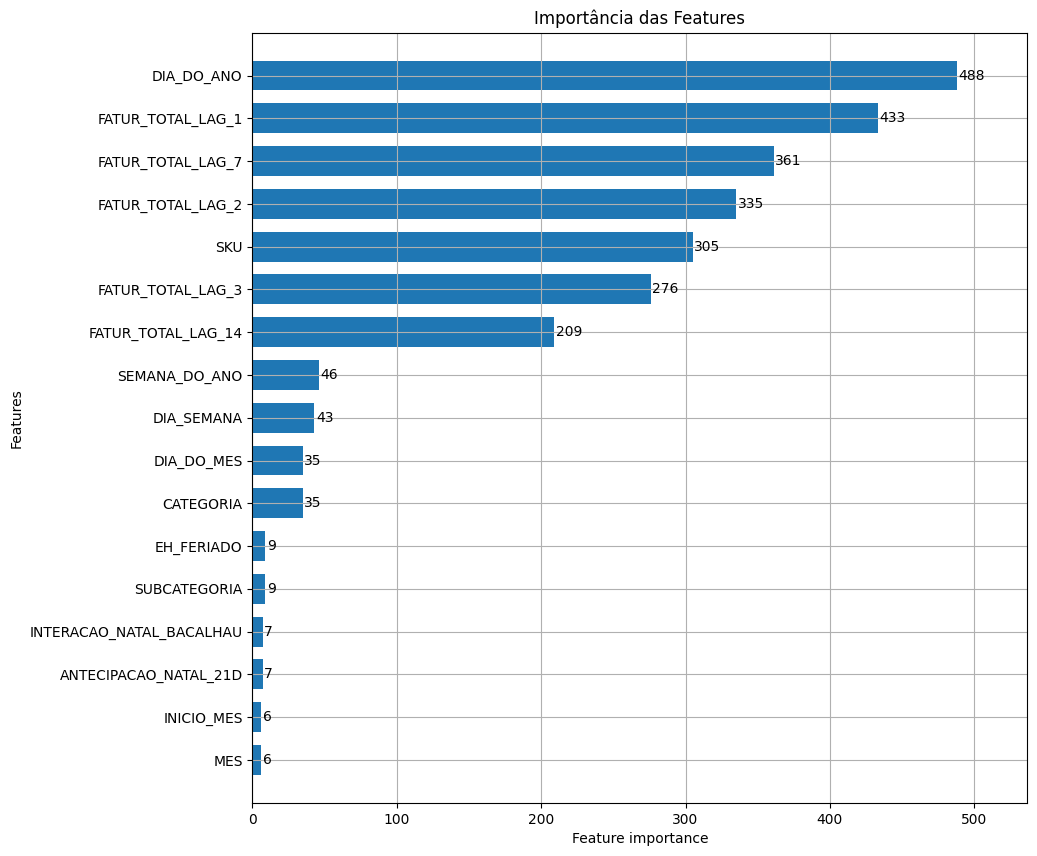

In [6]:
print("Plotando a importância das features...")

# Plotar a importância das features
lgb.plot_importance(model, figsize=(10, 10), max_num_features=25, height=0.7)
plt.title("Importância das Features")
plt.show()

### **7. Análise de Erros (Foco no SKU 1813)**

Visão Geral: Para responder diretamente à Pergunta 1 do case, esta etapa isola as previsões para o SKU 1813 (o Bacalhau) dentro do período de validação. É plotado um gráfico comparando o FATUR_TOTAL (Real) com o Previsto. Isto permite-nos avaliar visualmente se o modelo conseguiu capturar os picos de demanda de fim de ano para este produto específico.

Analisando performance específica para o SKU 1813...

--- Análise SKU 1813 (Período de Validação) ---
Faturamento Médio Real (SKU 1813): R$ 4,188.09
MAE Específico (SKU 1813):         R$ 2,749.72
Erro Percentual (SKU 1813):       65.66%


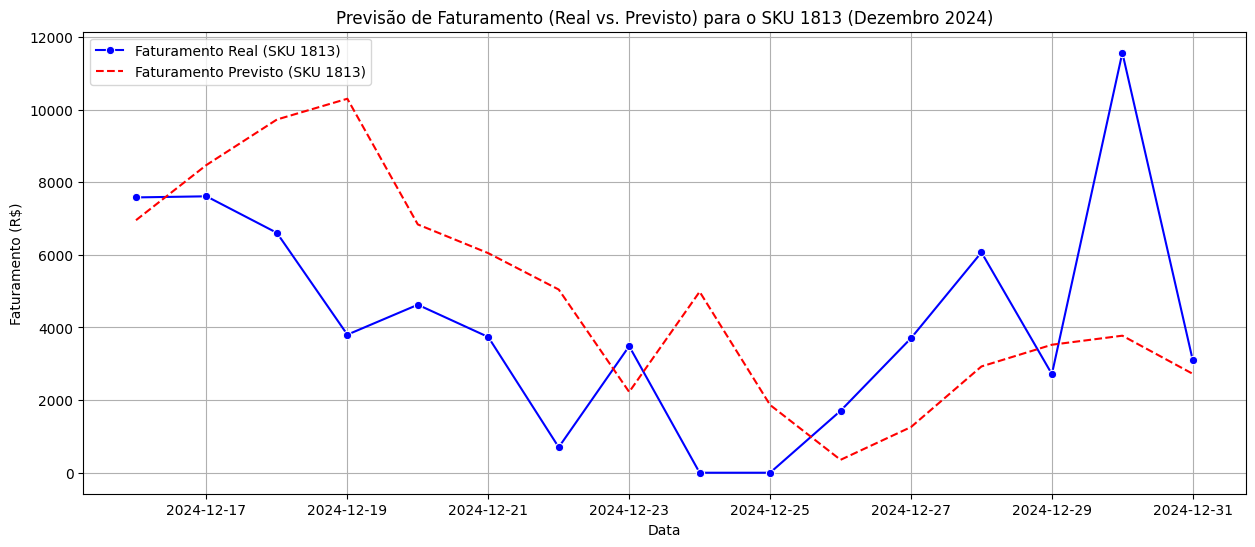

In [7]:
print("Analisando performance específica para o SKU 1813...")

# Junta as previsões de volta ao df_val original
df_val_results = df_val.copy()
df_val_results['Previsto'] = y_pred
df_val_results[TARGET] = y_val

# Filtra para o SKU 1813
# Certifique-se de que o SKU 1813 (numérico) está sendo usado para o filtro
df_sku_1813 = df_val_results[df_val_results['SKU'] == 1813].copy()
df_sku_1813['DATA_ATEND'] = pd.to_datetime(df_sku_1813['DATA_ATEND'])

# Calcula o MAE específico
sku_1813_mae = mean_absolute_error(df_sku_1813[TARGET], df_sku_1813['Previsto'])
sku_1813_fatur_medio = df_sku_1813[TARGET].mean()

print(f"\n--- Análise SKU 1813 (Período de Validação) ---")
print(f"Faturamento Médio Real (SKU 1813): R$ {sku_1813_fatur_medio:,.2f}")
print(f"MAE Específico (SKU 1813):         R$ {sku_1813_mae:,.2f}")

# Evita divisão por zero se o faturamento médio for 0
if sku_1813_fatur_medio > 0:
    print(f"Erro Percentual (SKU 1813):       {sku_1813_mae / sku_1813_fatur_medio * 100:,.2f}%")
else:
    print("SKU 1813 não teve faturamento no período de validação.")


# Plotar a série temporal Real vs. Previsto para o SKU 1813
if not df_sku_1813.empty:
    plt.figure(figsize=(15, 6))
    sns.lineplot(data=df_sku_1813, x='DATA_ATEND', y=TARGET, label='Faturamento Real (SKU 1813)', color='blue', marker='o')
    sns.lineplot(data=df_sku_1813, x='DATA_ATEND', y='Previsto', label='Faturamento Previsto (SKU 1813)', color='red', linestyle='--')
    plt.title('Previsão de Faturamento (Real vs. Previsto) para o SKU 1813 (Dezembro 2024)')
    plt.ylabel('Faturamento (R$)')
    plt.xlabel('Data')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("SKU 1813 não encontrado no set de validação.")

In [8]:
print("--- 1. Verificação do Tamanho dos Datasets (Linhas, Colunas) ---")
print(f"Dataset de Treino (X_train): {X_train.shape}")
print(f"Dataset de Validação (X_val): {X_val.shape}")
print("-" * 60)


print("\n--- 2. Importância das Features (O que o modelo usou) ---")
# Cria um DataFrame com a importância das features
df_importancia = pd.DataFrame({
    'feature': model.feature_name_,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

# Imprime o DataFrame de importância
print(df_importancia.to_string())
print("-" * 60)


print("\n--- 3. Verificação Específica do SKU 1813 (Real vs. Previsto) ---")
# Re-cria o dataframe de resultados (caso não exista)
df_val_results = df_val.copy()
df_val_results['Previsto'] = y_pred
df_val_results[TARGET] = y_val

# Filtra para o SKU 1813
df_sku_1813_debug = df_val_results[df_val_results['SKU'] == 1813].copy()
df_sku_1813_debug['DATA_ATEND'] = pd.to_datetime(df_sku_1813_debug['DATA_ATEND'])

# Seleciona e imprime as colunas que você pediu
colunas_debug = ['DATA_ATEND', TARGET, 'Previsto']
print(df_sku_1813_debug[colunas_debug].to_string(float_format='%.2f'))
print("-" * 60)

--- 1. Verificação do Tamanho dos Datasets (Linhas, Colunas) ---
Dataset de Treino (X_train): (20650, 23)
Dataset de Validação (X_val): (944, 23)
------------------------------------------------------------

--- 2. Importância das Features (O que o modelo usou) ---
                        feature  importance
5                    DIA_DO_ANO         488
18            FATUR_TOTAL_LAG_1         433
21            FATUR_TOTAL_LAG_7         361
19            FATUR_TOTAL_LAG_2         335
0                           SKU         305
20            FATUR_TOTAL_LAG_3         276
22           FATUR_TOTAL_LAG_14         209
7                 SEMANA_DO_ANO          46
3                    DIA_SEMANA          43
1                     CATEGORIA          35
4                    DIA_DO_MES          35
14                   EH_FERIADO           9
2                  SUBCATEGORIA           9
12        ANTECIPACAO_NATAL_21D           7
16     INTERACAO_NATAL_BACALHAU           7
9                    INICIO_ME